Main

In [ ]:
# Install dependencies
!pip install transformers accelerate beautifulsoup4 requests --quiet

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import requests
from bs4 import BeautifulSoup
import re
import torch
import ast
import operator

# Load model and tokenizer
model_name = "EleutherAI/pythia-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = 0 if torch.cuda.is_available() else -1
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=device)

# Simple safe eval for math expressions
# Supports + - * / ** and parentheses only
allowed_operators = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expr):
    try:
        node = ast.parse(expr, mode='eval')

        def _eval(node):
            if isinstance(node, ast.Expression):
                return _eval(node.body)
            elif isinstance(node, ast.Num):  # <number>
                return node.n
            elif isinstance(node, ast.BinOp):
                if type(node.op) not in allowed_operators:
                    raise ValueError("Unsupported operator")
                return allowed_operators[type(node.op)](_eval(node.left), _eval(node.right))
            elif isinstance(node, ast.UnaryOp):
                if type(node.op) not in allowed_operators:
                    raise ValueError("Unsupported unary operator")
                return allowed_operators[type(node.op)](_eval(node.operand))
            else:
                raise ValueError("Unsupported expression")
        return _eval(node)
    except Exception:
        return None

# Web scraping for context
def scrape_web(query, max_sentences=3):
    print(" Searching the web...")
    headers = {"User-Agent": "Mozilla/5.0"}
    search_url = f"https://www.google.com/search?q={query.replace(' ', '+')}"
    try:
        response = requests.get(search_url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        results = soup.find_all("div", class_="BNeawe s3v9rd AP7Wnd")
        text = " ".join([r.get_text() for r in results])
        text = re.sub(r'\s+', ' ', text)
        sentences = text.split(". ")
        return ". ".join(sentences[:max_sentences]) + "."
    except Exception:
        return "Sorry, I couldn't retrieve relevant information from the web."

# Classify subject
def classify_subject(query):
    query_lower = query.lower()
    if any(word in query_lower for word in ["equation", "geometry", "multiply", "divide", "percentage", "algebra", "area", "volume", "math", "+", "-", "*", "/"]):
        return "Math"
    elif any(word in query_lower for word in ["gravity", "photosynthesis", "cell", "atoms", "electricity", "force", "biology", "physics", "science"]):
        return "Science"
    elif any(word in query_lower for word in ["history", "freedom", "independence", "constitution", "government", "society", "social", "culture", "geography"]):
        return "Social Studies"
    else:
        return "General"

# Generate answer: first try math eval, else LLM + RAG
def generate_answer(query):
    subject = classify_subject(query)

    # If math, try to eval
    if subject == "Math":
        # Extract expression, naive approach: remove words, keep numbers/operators
        expr = re.sub(r'[^0-9+\-*/(). ]', '', query)
        result = safe_eval(expr)
        if result is not None:
            return f"The answer is {result}."

    # Else use model + context
    context = scrape_web(query)
    prompt = (
        f"You are a helpful school tutor for {subject}. "
        f"Use the following context to answer the student's question clearly in one short sentence.\n\n"
        f"Context: {context}\n"
        f"Question: {query}\n"
        f"Answer:"
    )

    output = generator(
        prompt,
        max_new_tokens=60,
        do_sample=False,
        truncation=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    generated = output[0]["generated_text"]

    if "Answer:" in generated:
        answer = generated.split("Answer:")[-1].strip()
    else:
        answer = generated.strip()

    # Limit to one sentence
    answer = answer.split(".")[0].strip() + "."

    if len(answer) < 3:
        return "Sorry, I couldn't find a clear answer. Try asking differently."

    return answer

# Chat interface
def chat():
    print(" School Support Chatbot (Pythia 1B + Web Context + Math Eval)")
    print("Subjects: Math, Science, Social Studies.")
    print("Type 'exit' to quit.\n")
    while True:
        user_input = input("You: ")
        if user_input.lower().strip() in ["exit", "quit"]:
            print(" Goodbye! Keep learning.")
            break
        answer = generate_answer(user_input)
        print(f" Bot: {answer}\n")

# Run chat
chat()


Device set to use cuda:0


 School Support Chatbot (Pythia 1B + Web Context + Math Eval)
Subjects: Math, Science, Social Studies.
Type 'exit' to quit.

You: 1+1
 Bot: The answer is 2.

You: what is photosynthesis


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 Searching the web...
 Bot: photosynthesis is the process of converting sunlight into chemical energy.

You: quit
 Goodbye! Keep learning.


With Audio Gen

In [ ]:
# Install only compatible versions
!pip install transformers==4.41.1 accelerate TTS beautifulsoup4 --quiet


In [ ]:
# Import libraries
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline # Changed GPT2Tokenizer to AutoTokenizer
from TTS.api import TTS
import requests
from bs4 import BeautifulSoup
import re
import torch
import ast
import operator
import os
import IPython.display as ipd

# Load model and tokenizer
model_name = "EleutherAI/pythia-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name) # Changed GPT2Tokenizer to AutoTokenizer
model = AutoModelForCausalLM.from_pretrained(model_name)
device = 0 if torch.cuda.is_available() else -1
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=device)

# Safe math evaluator
allowed_operators = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expr):
    try:
        node = ast.parse(expr, mode='eval')
        def _eval(n):
            if isinstance(n, ast.Expression): return _eval(n.body)
            elif isinstance(n, ast.Num): return n.n
            elif isinstance(n, ast.BinOp): return allowed_operators[type(n.op)](_eval(n.left), _eval(n.right))
            elif isinstance(n, ast.UnaryOp): return allowed_operators[type(n.op)](_eval(n.operand))
            else: raise ValueError("Invalid")
        return _eval(node)
    except:
        return None

# Scrape simple web info
def scrape_web(query, max_sentences=3):
    print("🔍 Searching the web...")
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        url = f"https://www.google.com/search?q={query.replace(' ', '+')}"
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        results = soup.find_all("div", class_="BNeawe s3v9rd AP7Wnd")
        text = " ".join([r.get_text() for r in results])
        text = re.sub(r'\s+', ' ', text)
        sentences = text.split(". ")
        return ". ".join(sentences[:max_sentences]) + "."
    except:
        return "Sorry, I couldn't retrieve relevant information from the web."

# Subject classifier
def classify_subject(query):
    query = query.lower()
    if any(w in query for w in ["equation", "+", "-", "*", "/", "area", "volume", "math"]):
        return "Math"
    if any(w in query for w in ["gravity", "biology", "physics", "science", "atom"]):
        return "Science"
    if any(w in query for w in ["history", "freedom", "india", "geography", "constitution"]):
        return "Social Studies"
    return "General"

# Generate answer
def generate_answer(query):
    subject = classify_subject(query)

    if subject == "Math":
        expr = re.sub(r'[^0-9+\-*/(). ]', '', query)
        result = safe_eval(expr)
        if result is not None:
            return f"The answer is {result}."

    context = scrape_web(query)
    prompt = (
        f"You are a helpful tutor for {subject}.\n"
        f"Context: {context}\n"
        f"Question: {query}\nAnswer:"
    )

    output = generator(prompt, max_new_tokens=60, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    response = output[0]["generated_text"].split("Answer:")[-1].strip()
    return response.split(".")[0].strip() + "."

# Load TTS model
tts_model = "tts_models/en/ljspeech/tacotron2-DDC"
tts = TTS(tts_model)

# Speak
def speak(text, filename="reply.wav"):
    tts.tts_to_file(text=text, file_path=filename)
    ipd.display(ipd.Audio(filename))

# Chat loop
def chat():
    print("🎓 School Assistant Chatbot with Voice")
    print("Type 'exit' to quit.\n")
    while True:
        query = input("You: ")
        if query.lower() in ['exit', 'quit']: break
        answer = generate_answer(query)
        print("Bot:", answer)
        speak(answer)

# Start chatbot
chat()

2

In [ ]:
!pip install transformers==4.41.1 accelerate TTS beautifulsoup4 --quiet


In [ ]:
# === Full Voice-Enabled Chatbot Code ===

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from TTS.api import TTS
import requests
from bs4 import BeautifulSoup
import re
import torch
import ast
import operator
import os
import IPython.display as ipd

# Load model and tokenizer
model_name = "EleutherAI/pythia-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = 0 if torch.cuda.is_available() else -1
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=device)

# Safe math evaluator
allowed_operators = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expr):
    try:
        node = ast.parse(expr, mode='eval')
        def _eval(n):
            if isinstance(n, ast.Expression):
                return _eval(n.body)
            elif isinstance(n, ast.Num):
                return n.n
            elif isinstance(n, ast.BinOp):
                return allowed_operators[type(n.op)](_eval(n.left), _eval(n.right))
            elif isinstance(n, ast.UnaryOp):
                return allowed_operators[type(n.op)](_eval(n.operand))
            else:
                raise ValueError("Invalid expression")
        return _eval(node)
    except:
        return None

# Web search scraper
def scrape_web(query, max_sentences=3):
    print("🔍 Searching the web...")
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        url = f"https://www.google.com/search?q={query.replace(' ', '+')}"
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        results = soup.find_all("div", class_="BNeawe s3v9rd AP7Wnd")
        text = " ".join([r.get_text() for r in results])
        text = re.sub(r'\s+', ' ', text)
        sentences = text.split(". ")
        return ". ".join(sentences[:max_sentences]) + "."
    except:
        return "Sorry, I couldn't retrieve relevant information from the web."

# Subject classifier
def classify_subject(query):
    query = query.lower()
    if any(w in query for w in ["equation", "+", "-", "*", "/", "area", "volume", "math"]):
        return "Math"
    if any(w in query for w in ["gravity", "biology", "physics", "science", "atom"]):
        return "Science"
    if any(w in query for w in ["history", "freedom", "india", "geography", "constitution"]):
        return "Social Studies"
    return "General"

# Answer generation
def generate_answer(query):
    subject = classify_subject(query)

    if subject == "Math":
        expr = re.sub(r'[^0-9+\-*/(). ]', '', query)
        result = safe_eval(expr)
        if result is not None:
            return f"The answer is {result}."

    context = scrape_web(query)
    prompt = (
        f"You are a helpful tutor for {subject}.\n"
        f"Context: {context}\n"
        f"Question: {query}\nAnswer:"
    )

    output = generator(prompt, max_new_tokens=60, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    response = output[0]["generated_text"].split("Answer:")[-1].strip()
    return response.split(".")[0].strip() + "."

# Text-to-Speech
tts_model = "tts_models/en/ljspeech/tacotron2-DDC"
tts = TTS(tts_model)

def speak(text, filename="reply.wav"):
    tts.tts_to_file(text=text, file_path=filename)
    ipd.display(ipd.Audio(filename))

# Chat loop
def chat():
    print("🎓 School Assistant Chatbot with Voice")
    print("Type 'exit' to quit.\n")
    while True:
        query = input("You: ")
        if query.lower() in ['exit', 'quit']:
            print("👋 Goodbye!")
            break
        answer = generate_answer(query)
        print("Bot:", answer)
        speak(answer)

# Start chatbot
chat()


5aud

In [ ]:
pip install transformers edge-tts beautifulsoup4 torch ipython


In [ ]:
# === Voice-Enabled Chatbot with Edge TTS (5 Voices) ===

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import requests
from bs4 import BeautifulSoup
import re
import torch
import ast
import operator
import os
import uuid
import asyncio
import edge_tts
import IPython.display as ipd

# Load model and tokenizer
model_name = "EleutherAI/pythia-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = 0 if torch.cuda.is_available() else -1
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=device)

# Safe math evaluator
allowed_operators = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expr):
    try:
        node = ast.parse(expr, mode='eval')
        def _eval(n):
            if isinstance(n, ast.Expression): return _eval(n.body)
            elif isinstance(n, ast.Num): return n.n
            elif isinstance(n, ast.BinOp): return allowed_operators[type(n.op)](_eval(n.left), _eval(n.right))
            elif isinstance(n, ast.UnaryOp): return allowed_operators[type(n.op)](_eval(n.operand))
            else: raise ValueError("Invalid expression")
        return _eval(node)
    except:
        return None

# Web scraping for context
def scrape_web(query, max_sentences=3):
    print("🔍 Searching the web...")
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        url = f"https://www.google.com/search?q={query.replace(' ', '+')}"
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        results = soup.find_all("div", class_="BNeawe s3v9rd AP7Wnd")
        text = " ".join([r.get_text() for r in results])
        text = re.sub(r'\s+', ' ', text)
        sentences = text.split(". ")
        return ". ".join(sentences[:max_sentences]) + "."
    except:
        return "Sorry, I couldn't retrieve relevant information from the web."

# Classify subject
def classify_subject(query):
    query = query.lower()
    if any(w in query for w in ["equation", "+", "-", "*", "/", "area", "volume", "math"]):
        return "Math"
    if any(w in query for w in ["gravity", "biology", "physics", "science", "atom"]):
        return "Science"
    if any(w in query for w in ["history", "freedom", "india", "geography", "constitution"]):
        return "Social Studies"
    return "General"

# Generate answer
def generate_answer(query):
    subject = classify_subject(query)

    # Handle math directly
    if subject == "Math":
        expr = re.sub(r'[^0-9+\-*/(). ]', '', query)
        result = safe_eval(expr)
        if result is not None:
            return f"The answer is {result}."

    # Scrape context
    context = scrape_web(query)

    # Prompt for generation
    prompt = (
        f"You are a highly knowledgeable tutor that gives clear, accurate, and detailed answers.\n"
        f"Subject: {subject}\n"
        f"Context (from the web): {context}\n"
        f"Question: {query}\n"
        f"Answer in 3 to 4 full sentences:"
    )

    output = generator(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    response = output[0]["generated_text"].split("Answer:")[-1].strip()
    response = re.split(r'(?<=[.!?]) +', response)
    return " ".join(response[:3]).strip()

# Edge TTS Voices
VOICES = [
    "en-US-JennyNeural",
    "en-GB-RyanNeural",
    "en-IN-NeerjaNeural",
    "en-US-GuyNeural",
    "en-AU-NatashaNeural"
]

# Generate speech using Edge TTS
async def speak_edge_tts(text, voice, filename):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(filename)

async def speak_multiple_voices(text):
    print("🔊 Generating speech in 5 different voices...")
    for i, voice in enumerate(VOICES):
        filename = f"voice_{i+1}_{uuid.uuid4().hex[:6]}.mp3"
        await speak_edge_tts(text, voice, filename)
        print(f"▶️ Voice {i+1} ({voice}):")
        ipd.display(ipd.Audio(filename))

# Main chat loop
async def chat():
    print("🎓 School Assistant Chatbot with Edge TTS Voice")
    print("Type 'exit' to quit.\n")
    while True:
        query = input("You: ")
        if query.lower() in ['exit', 'quit']:
            print("👋 Goodbye!")
            break
        answer = generate_answer(query)
        print("Bot:", answer)
        await speak_multiple_voices(answer)

# Start chatbot
await chat()

best

In [ ]:
pip install transformers torch edge-tts beautifulsoup4 requests


In [ ]:
# === Voice-Enabled Chatbot with Improved Accuracy and Edge TTS ===

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import requests
from bs4 import BeautifulSoup
import re
import torch
import ast
import operator
import os
import uuid
import asyncio
import edge_tts
import IPython.display as ipd

# Load model and tokenizer
model_name = "EleutherAI/pythia-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = 0 if torch.cuda.is_available() else -1
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=device)

# Safe math evaluator
allowed_operators = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expr):
    try:
        node = ast.parse(expr, mode='eval')
        def _eval(n):
            if isinstance(n, ast.Expression): return _eval(n.body)
            elif isinstance(n, ast.Num): return n.n
            elif isinstance(n, ast.BinOp): return allowed_operators[type(n.op)](_eval(n.left), _eval(n.right))
            elif isinstance(n, ast.UnaryOp): return allowed_operators[type(n.op)](_eval(n.operand))
            else: raise ValueError("Invalid expression")
        return _eval(node)
    except:
        return None

# Web scraping for context
def scrape_web(query, max_sentences=3):
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        url = f"https://www.google.com/search?q={query.replace(' ', '+')}"
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        results = soup.find_all("div", class_="BNeawe s3v9rd AP7Wnd")
        text = " ".join([r.get_text() for r in results])
        text = re.sub(r'\s+', ' ', text)
        sentences = text.split(". ")
        return ". ".join(sentences[:max_sentences]) + "."
    except:
        return "Sorry, I couldn't retrieve relevant information from the web."

# Classify subject
def classify_subject(query):
    query = query.lower()
    if any(w in query for w in ["equation", "+", "-", "*", "/", "area", "volume", "math"]):
        return "Math"
    if any(w in query for w in ["gravity", "biology", "physics", "science", "atom"]):
        return "Science"
    if any(w in query for w in ["history", "freedom", "india", "geography", "constitution"]):
        return "Social Studies"
    return "General"

# Improved answer generation
def generate_answer(query):
    subject = classify_subject(query)

    # Handle math directly
    if subject == "Math":
        expr = re.sub(r'[^0-9+\-*/(). ]', '', query)
        result = safe_eval(expr)
        if result is not None:
            return f"The answer is {result}."

    # Get context
    context = scrape_web(query)
    if not context or "couldn't retrieve" in context:
        context = "No external context was available. Use your own knowledge."

    # Better prompt
    prompt = (
        f"You are a helpful and intelligent tutor. Answer the question clearly in 2-3 sentences.\n"
        f"Subject: {subject}\n"
        f"Context: {context}\n"
        f"Question: {query}\n"
        f"Answer:"
    )

    output = generator(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    # Extract and clean response
    generated_text = output[0]["generated_text"]
    answer = generated_text.split("Answer:")[-1].strip()
    answer = re.sub(r'\n+', ' ', answer)
    answer = re.sub(r'[^a-zA-Z0-9,.\-()\'" ]+', '', answer)
    sentences = re.split(r'(?<=[.!?]) +', answer)
    final_answer = " ".join(sentences[:3]).strip()

    if len(final_answer) < 10 or "I don't know" in final_answer.lower():
        return "Sorry, I couldn’t generate a clear answer. Could you rephrase that?"

    return final_answer

# Edge TTS Voices
VOICES = [
    "en-US-JennyNeural",
    "en-GB-RyanNeural",
    "en-IN-NeerjaNeural",
    "en-US-GuyNeural",
    "en-AU-NatashaNeural"
]

# Generate speech using Edge TTS
async def speak_edge_tts(text, voice, filename):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(filename)

async def speak_multiple_voices(text):
    print("🔊 Speaking in 5 voices...\n")
    for i, voice in enumerate(VOICES):
        filename = f"voice_{i+1}_{uuid.uuid4().hex[:6]}.mp3"
        await speak_edge_tts(text, voice, filename)
        print(f"▶️ Voice {i+1} ({voice}):")
        ipd.display(ipd.Audio(filename))

# Main chat loop
async def chat():
    print("🎓 Smart Voice Chatbot (Clean Output)")
    print("Type 'exit' to quit.\n")
    while True:
        query = input("You: ")
        if query.lower() in ['exit', 'quit']:
            print("👋 Goodbye!")
            break
        answer = generate_answer(query)
        print("Bot:", answer)
        await speak_multiple_voices(answer)

# Run chatbot
await chat()


main

In [ ]:
# === Voice-Enabled Chatbot with Improved Output and Edge TTS ===

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import requests
from bs4 import BeautifulSoup
import re
import torch
import ast
import operator
import os
import uuid
import asyncio
import edge_tts
import IPython.display as ipd

# Load model and tokenizer
model_name = "EleutherAI/pythia-1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = 0 if torch.cuda.is_available() else -1
generator = pipeline("text-generation", model=model, tokenizer=tokenizer, device=device)

# Safe math evaluator
allowed_operators = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expr):
    try:
        node = ast.parse(expr, mode='eval')
        def _eval(n):
            if isinstance(n, ast.Expression): return _eval(n.body)
            elif isinstance(n, ast.Num): return n.n
            elif isinstance(n, ast.BinOp): return allowed_operators[type(n.op)](_eval(n.left), _eval(n.right))
            elif isinstance(n, ast.UnaryOp): return allowed_operators[type(n.op)](_eval(n.operand))
            else: raise ValueError("Invalid expression")
        return _eval(node)
    except:
        return None

# Web scraping for context
def scrape_web(query, max_sentences=3):
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        url = f"https://www.google.com/search?q={query.replace(' ', '+')}"
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")
        results = soup.find_all("div", class_="BNeawe s3v9rd AP7Wnd")
        text = " ".join([r.get_text() for r in results])
        text = re.sub(r'\s+', ' ', text)
        sentences = text.split(". ")
        return ". ".join(sentences[:max_sentences]) + "."
    except:
        return "Sorry, I couldn't retrieve relevant information from the web."

# Classify subject
def classify_subject(query):
    query = query.lower()
    if any(w in query for w in ["equation", "+", "-", "*", "/", "area", "volume", "math"]):
        return "Math"
    if any(w in query for w in ["gravity", "biology", "physics", "science", "atom"]):
        return "Science"
    if any(w in query for w in ["history", "freedom", "india", "geography", "constitution"]):
        return "Social Studies"
    return "General"

# Improved answer generation with clean output
def generate_answer(query):
    subject = classify_subject(query)

    # Handle math directly
    if subject == "Math":
        expr = re.sub(r'[^0-9+\-*/(). ]', '', query)
        result = safe_eval(expr)
        if result is not None:
            return f"The answer is {result}."

    # Get context
    context = scrape_web(query)
    if not context or "couldn't retrieve" in context:
        context = "No external context was available. Use your own knowledge."

    # Prompt
    prompt = (
        f"You are a helpful and intelligent tutor. Respond in 1–2 clear sentences.\n"
        f"Subject: {subject}\n"
        f"Context: {context}\n"
        f"Question: {query}\n"
        f"Answer:"
    )

    output = generator(
        prompt,
        max_new_tokens=150,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    # Extract generated content
    generated_text = output[0]["generated_text"]
    answer_raw = generated_text.split("Answer:")[-1].strip()

    # Remove repeated "The answer is" fragments
    answer_clean = re.sub(r"(The answer is:\s*)+", "", answer_raw, flags=re.IGNORECASE)

    # Split into sentences and remove duplicates
    sentences = re.split(r'(?<=[.!?]) +', answer_clean)
    seen = set()
    unique_sentences = []
    for sentence in sentences:
        s_clean = sentence.strip().lower()
        if s_clean and s_clean not in seen:
            seen.add(s_clean)
            unique_sentences.append(sentence.strip())

    # Limit to 1–2 sentences
    final_answer = " ".join(unique_sentences[:2])
    if not final_answer.endswith(('.', '!', '?')):
        final_answer += "."

    if len(final_answer) < 10 or "i don't know" in final_answer.lower():
        return "Sorry, I couldn’t generate a clear answer. Could you rephrase that?"

    return final_answer

# Edge TTS Voices
VOICES = [
    "en-US-JennyNeural",
    "en-GB-RyanNeural",
    "en-IN-NeerjaNeural",
    "en-US-GuyNeural",
    "en-AU-NatashaNeural"
]

# Generate speech using Edge TTS
async def speak_edge_tts(text, voice, filename):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(filename)

async def speak_multiple_voices(text):
    print("🔊 Speaking in 5 voices...\n")
    for i, voice in enumerate(VOICES):
        filename = f"voice_{i+1}_{uuid.uuid4().hex[:6]}.mp3"
        await speak_edge_tts(text, voice, filename)
        print(f"▶️ Voice {i+1} ({voice}):")
        ipd.display(ipd.Audio(filename))

# Main chat loop
async def chat():
    print("🎓 Smart Voice Chatbot (Clean Output)")
    print("Type 'exit' to quit.\n")
    while True:
        query = input("You: ")
        if query.lower() in ['exit', 'quit']:
            print("👋 Goodbye!")
            break
        answer = generate_answer(query)
        print("Bot:", answer)
        await speak_multiple_voices(answer)

# Run chatbot
await chat()


ModuleNotFoundError: No module named 'edge_tts'

FINAL CODE

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 4.1.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.35.2 which is incompatible.
peft 0.16.0 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.1 which is incompatible.


/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[Info] Loading GPT-Neo 1.3B model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


  0%|          | 0/50 [00:00<?, ?it/s]

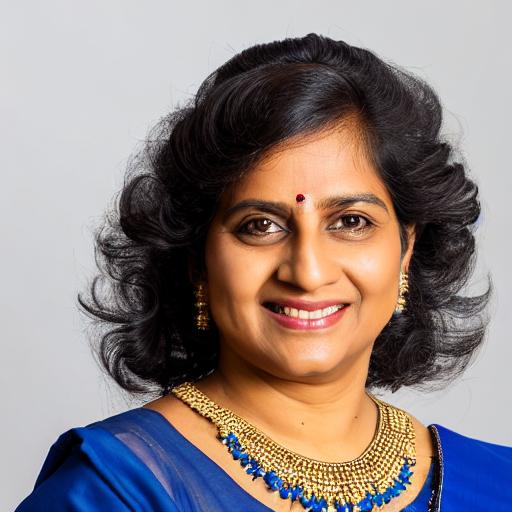

✅ Avatar saved as avatar.jpg
Cloning into 'SadTalker'...
remote: Enumerating objects: 1605, done.
remote: Counting objects: 100% (544/544), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 1605 (delta 468), reused 441 (delta 441), pack-reused 1061 (from 1)
Receiving objects: 100% (1605/1605), 92.20 MiB | 32.48 MiB/s, done.
Resolving deltas: 100% (869/869), done.
/content/SadTalker
--2025-07-22 16:29:36--  https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2-rc/mapping_00109-model.pth.tar
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/569518584/ccc415aa-c6f4-47ee-8250-b10bf440ba62?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-07-22T17%3A29%3A14Z&rscd=attachment%3B+filename%3Dmapping_00109-model.pth.tar&rsct=application%2Foctet-stream&skoid=96c2d410-57

In [1]:
# ===============================
# 1. Install Required Libraries
# ===============================
!pip install --upgrade --quiet transformers==4.39.3 huggingface_hub==0.23.1
!pip install -q gTTS
!pip uninstall -y jax jaxlib flax optax orbax-checkpoint
!pip install diffusers==0.20.2 transformers==4.35.2 huggingface_hub==0.23.1 --quiet
!pip install pydub --quiet

# ===============================
# 2. Generate Script using GPT-Neo
# ===============================
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

def generate_script(topic):
    print("[Info] Loading GPT-Neo 1.3B model...")
    tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-1.3B")
    model = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-1.3B")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    prompt = f"Explain the topic: {topic}\n\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=500,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    script_text = full_text.replace(prompt, "").strip()

    if not script_text or len(script_text) < 20:
        raise ValueError("Script generation failed. Try changing the topic or adjusting generation settings.")

    with open("script.txt", "w") as f:
        f.write(script_text)

    print("✅ Script saved as script.txt")
    return script_text

# Example usage
topic = "Quantum Computing"
script_text = generate_script(topic)
print("\nGenerated Script:\n", script_text)

# ===============================
# 3. Convert Script to Speech
# ===============================
from gtts import gTTS
from IPython.display import Audio, display

def generate_voice(script, lang="en"):
    if not script or len(script.strip()) < 10:
        raise ValueError("⚠️ Script is empty or too short for TTS.")

    tts = gTTS(text=script, lang=lang)
    tts.save("audio.mp3")
    print("✅ Audio saved as audio.mp3")
    return "audio.mp3"

# Read script and convert
with open("script.txt", "r") as f:
    script_text = f.read()

# Generate and play audio
audio_path = generate_voice(script_text)
display(Audio(audio_path))

# ===============================
# 4. Generate Avatar with Stable Diffusion
# ===============================
from diffusers import StableDiffusionPipeline
from IPython.display import Image, display as img_display

def generate_avatar_image(prompt):
    negative_prompt = "blurry, distorted, deformed face, cartoon, low quality"

    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")

    image = pipe(prompt=prompt, negative_prompt=negative_prompt).images[0]
    image.save("avatar.jpg")
    img_display(Image(filename="avatar.jpg"))
    print("✅ Avatar saved as avatar.jpg")
    return "avatar.jpg"

# Example avatar prompt
avatar_prompt = "realistic portrait of confident Indian female teacher, smiling, professional attire, clean white background, sharp focus, well-lit"
avatar_path = generate_avatar_image(avatar_prompt)

# ===============================
# 5. Setup SadTalker
# ===============================
!git clone https://github.com/OpenTalker/SadTalker.git
%cd SadTalker
!bash scripts/download_models.sh
!pip install -r requirements.txt --quiet
!pip install facexlib --no-deps --quiet
!pip install basicsr --no-deps --quiet
!pip install torch==2.0.1 torchvision==0.15.2 --force-reinstall --quiet
!pip install numpy==1.23.5 --force-reinstall --quiet
!pip uninstall -y imageio
!pip install imageio==2.31.1 --quiet

# ===============================
# 6. Prepare Files for Animation
# ===============================
import shutil
import sys
from pydub import AudioSegment

shutil.copy("/content/avatar.jpg", "avatar.jpg")
shutil.copy("/content/audio.mp3", "audio.mp3")

# Trim audio to 15 seconds
sys.setrecursionlimit(20000)
audio = AudioSegment.from_file("audio.mp3")
short_audio = audio[:15000]
short_audio.export("audio.mp3", format="mp3")
print("✅ Trimmed audio to 15 seconds.")

# ===============================
# 7. Generate Talking Avatar Video
# ===============================
!python inference.py \
  --driven_audio audio.mp3 \
  --source_image avatar.jpg \
  --result_dir results \
  --still \
  --enhancer gfpgan

# ===============================
# 8. Show Result Video
# ===============================
import os
from IPython.display import Video

# Find generated video
for root, dirs, files in os.walk("results"):
    for name in files:
        if name.endswith(".mp4"):
            result_path = os.path.join(root, name)
            print("✅ Video generated:", result_path)
            display(Video(result_path, embed=True))
